# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from model import GradientBoostingModel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [4]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
# heart_path = Path('data/heart.csv')
heart_path = Path('/Users/ashleyxu/cs1851/stencil/homework2/data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
print(X_heart.shape, y_heart.value_counts().to_dict())

# Cancer genomics dataset
# cancer_path = Path('data/cancer_genomics.csv')
# labels_path = Path('data/labels_cancer_genomics.csv')
cancer_path = Path('/Users/ashleyxu/cs1851/stencil/homework2/data/cancer_genomics.csv')
labels_path = Path('/Users/ashleyxu/cs1851/stencil/homework2/data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)
print(X_cancer.shape, y_cancer.value_counts().to_dict())


Successfully loaded heart disease data with 1025 rows
(1025, 13) {1: 526, 0: 499}
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}


In [5]:
# TODO: Initialize your model (adjust params)
model = GradientBoostingModel(
    task='classification',
    # max_depth=...,
    # learning_rate=...,
    # n_estimators=...,
    # use_scaler=...,
    max_depth=3,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False,
)


In [51]:
# TODO: Train/test split + fit (heart)
# X_train, X_test, y_train, y_test = model.train_test_split(...)
# model.fit(X_train, y_train)
X_train, X_test, y_train, y_test = model.train_test_split(X_heart, y_heart)
model.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.2784            0.12s
         2           1.1866            0.09s
         3           1.1129            0.08s
         4           1.0473            0.08s
         5           0.9846            0.07s
         6           0.9371            0.07s
         7           0.8898            0.06s
         8           0.8506            0.06s
         9           0.8135            0.06s
        10           0.7814            0.06s
        20           0.5716            0.04s
        30           0.4555            0.03s
        40           0.3883            0.01s
        50           0.3309            0.00s


In [52]:
# TODO: Evaluate (heart)
# metrics = model.evaluate(...)
# print metrics
metrics = model.evaluate(X_test, y_test)
print(metrics)

{'accuracy': 0.8975609756097561, 'precision': 0.8995215311004785, 'recall': 0.897391966495336, 'f1': 0.897404732966326, 'roc_auc': 0.968303826384923}


In [42]:
# TODO: Cross-validation (heart)
# cv_results = model.cross_validate(...)
# print metrics
cv_results = model.cross_validate(X_heart, y_heart)
print(cv_results)

{'accuracy': (0.9473170731707317, 0.008392512455651324), 'precision': (0.9371628148666484, 0.01152763540225626), 'recall': (0.9620125786163521, 0.010236343677772862), 'f1': (0.9493646193257081, 0.007936233938412718), 'roc_auc': (0.9813686950366195, 0.009396783108376706)}


     Feature  Importance
0        age    0.050962
1        sex    0.021163
2         cp    0.286104
3   trestbps    0.030444
4       chol    0.045539
5        fbs    0.000000
6    restecg    0.004827
7    thalach    0.046694
8      exang    0.021780
9    oldpeak    0.116869
10     slope    0.042440
11        ca    0.170406
12      thal    0.162773
     Feature  Importance
2         cp    0.286104
11        ca    0.170406
12      thal    0.162773
9    oldpeak    0.116869
0        age    0.050962
7    thalach    0.046694
4       chol    0.045539
10     slope    0.042440
3   trestbps    0.030444
8      exang    0.021780


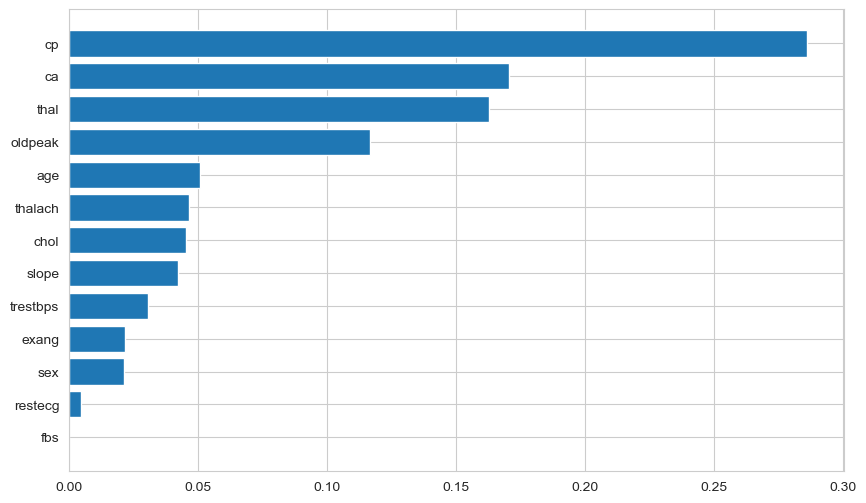

In [111]:
# TODO: Feature importance (heart)
# model.get_feature_importance(plot=False)
feature_importance = model.get_feature_importance(plot=True)
print(feature_importance)
# print(feature_importance.head(10))
print(feature_importance.nlargest(10, "Importance")) # added this line


In [109]:
# TODO: Hyperparameter tuning (heart)
param_grid = {
    # 'max_depth': [...],
    # 'n_estimators': [...],
    # 'learning_rate': [...],
    'max_depth': [3, 10, 20],
    'n_estimators': [20, 50, 100],
    'learning_rate': [0.001, 0.01, 0.1],
}
# tuning_results = model.tune_hyperparameters(X_heart, y_heart, param_grid, cv=3)
# print(tuning_results['best_params'])
# print(tuning_results['best_score'])

full_tuning_results, best_tuning_results = model.tune_hyperparameters(X_heart, y_heart, param_grid, cv=3)
print(best_tuning_results)
pd.DataFrame(full_tuning_results)


{'best_params': {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 50}, 'best_cv_score': 0.9887014814058318, 'best_score': 1.0}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.060014,0.005341,0.006450,0.004074,0.001,3,20,"{'learning_rate': 0.001, 'max_depth': 3, 'n_es...",0.915979,0.887322,0.886162,0.896488,0.013791,26
1,0.172351,0.039379,0.016664,0.012660,0.001,3,50,"{'learning_rate': 0.001, 'max_depth': 3, 'n_es...",0.915979,0.887322,0.884768,0.896023,0.014150,27
2,0.332825,0.018616,0.013350,0.013060,0.001,3,100,"{'learning_rate': 0.001, 'max_depth': 3, 'n_es...",0.930180,0.888417,0.884062,0.900886,0.020790,25
3,0.174937,0.005757,0.013859,0.012733,0.001,10,20,"{'learning_rate': 0.001, 'max_depth': 10, 'n_e...",0.995791,0.990279,0.978158,0.988076,0.007365,3
4,0.477340,0.020230,0.008844,0.003682,0.001,10,50,"{'learning_rate': 0.001, 'max_depth': 10, 'n_e...",0.992044,0.983023,0.976506,0.983858,0.006371,14
5,0.873446,0.063964,0.007295,0.002492,0.001,10,100,"{'learning_rate': 0.001, 'max_depth': 10, 'n_e...",0.988862,0.989663,0.974441,0.984322,0.006995,11
6,0.179931,0.014663,0.004155,0.000548,0.001,20,20,"{'learning_rate': 0.001, 'max_depth': 20, 'n_e...",0.995791,0.990074,0.978158,0.988008,0.007345,4
7,0.506890,0.011244,0.008897,0.006035,0.001,20,50,"{'learning_rate': 0.001, 'max_depth': 20, 'n_e...",0.992044,0.983023,0.976506,0.983858,0.006371,14
8,0.988423,0.053476,0.011902,0.004891,0.001,20,100,"{'learning_rate': 0.001, 'max_depth': 20, 'n_e...",0.989632,0.989663,0.974441,0.984579,0.007169,10
9,0.055567,0.007861,0.004192,0.001348,0.010,3,20,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.938768,0.889290,0.890516,0.906192,0.023041,24


In [40]:
print(X_cancer.columns)
print(X_cancer.values)
print(np.std(X_cancer.values))
print(np.min(X_cancer.values))
print(np.max(X_cancer.values))

Index(['gene_18', 'gene_21', 'gene_26', 'gene_28', 'gene_29', 'gene_30',
       'gene_31', 'gene_33', 'gene_39', 'gene_44',
       ...
       'gene_20466', 'gene_20472', 'gene_20476', 'gene_20484', 'gene_20490',
       'gene_20500', 'gene_20504', 'gene_20514', 'gene_20524', 'gene_20529'],
      dtype='object', length=5479)
[[0.59187087 0.         7.21511554 ... 7.12888107 7.22003001 5.28675919]
 [0.         0.         9.94981212 ... 6.04755802 6.25658612 2.09416849]
 [1.68302267 3.66042667 6.0966498  ... 6.66149309 5.40160658 1.68302267]
 ...
 [1.00259452 5.17982153 1.32509854 ... 8.40182669 3.58976349 4.6774575 ]
 [0.         0.         3.45093409 ... 8.12254331 4.74588807 5.71875068]
 [0.         4.70910312 3.48524648 ... 7.19475685 9.13945926 4.55071601]]
3.4649412778142956
0.0
20.7788287118


In [54]:
# TODO: Train/evaluate on cancer dataset (multi-class)
# cancer_model = GradientBoostingModel(...)
# cancer_model.train_test_split(...)
# fit
# evaluate 
# print metrics
cancer_model = GradientBoostingModel(
    task='classification',
    max_depth=3,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False
)
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = cancer_model.train_test_split(X_cancer, y_cancer)
cancer_model.fit(X_train, y_train)
cancer_metrics = cancer_model.evaluate(X_test_cancer, y_test_cancer)
print(cancer_metrics)


      Iter       Train Loss   Remaining Time 
         1           1.1337            2.99m
         2           0.9033            3.54m
         3           0.7357            3.70m
         4           0.6066            3.75m
         5           0.5041            3.74m
         6           0.4213            3.77m
         7           0.3535            3.71m
         8           0.2974            3.65m
         9           0.2509            3.58m
        10           0.2120            3.50m
        20           0.0413            2.71m
        30           0.0083            1.82m
        40           0.0017           54.73s
        50           0.0003            0.00s
{'accuracy': 0.9937888198757764, 'precision': 0.9967741935483871, 'recall': 0.993103448275862, 'f1': 0.9948652118100128, 'roc_auc': 0.9999149665107833}


In [96]:
cancer_cv_results = cancer_model.cross_validate(X_cancer, y_cancer)
print(cancer_cv_results)


{'accuracy': (0.986273291925466, 0.006104854691187139), 'precision_macro': (0.991531772226752, 0.00326352479973478), 'recall_macro': (0.9833128078817734, 0.008229881945071774), 'f1_macro': (0.9870345257966233, 0.005876334713557647), 'roc_auc_ovr': (0.9998028291878669, 0.0002334600515504683)}


         Feature  Importance
5167  gene_18746    0.289857
3674  gene_12983    0.202906
4434  gene_15895    0.181102
3498  gene_12013    0.114788
5004  gene_18135    0.110769
2368   gene_8014    0.054029
2772   gene_9176    0.017862
1808   gene_6160    0.006123
2032   gene_6876    0.004364
57      gene_203    0.004243


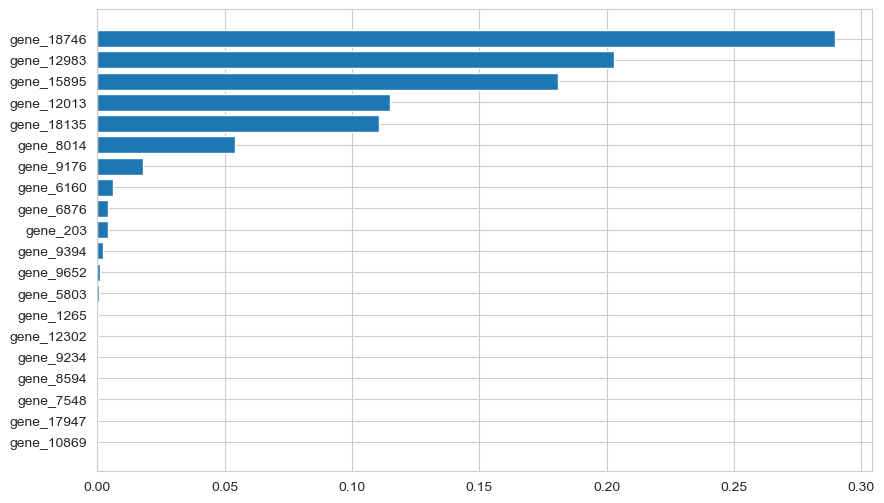

In [60]:
cancer_feature_importance = cancer_model.get_feature_importance(plot=True)
print(cancer_feature_importance.nlargest(10, "Importance"))

In [110]:
param_grid = {
    'max_depth': [3, 10, 20],
    'n_estimators': [20, 50, 100],
    'learning_rate': [0.001, 0.01, 0.1],
}
cancer_tuning_full_results, cancer_tuning_best_results = cancer_model.tune_hyperparameters(X_cancer, y_cancer, param_grid, cv=3)
print(cancer_tuning_best_results)
pd.DataFrame(cancer_tuning_full_results)

{'best_params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}, 'best_cv_score': 0.9998511123201976, 'best_score': 1.0}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,155.550839,1.675718,0.071280,0.010140,0.001,3,20,"{'learning_rate': 0.001, 'max_depth': 3, 'n_es...",0.999750,0.999649,0.997148,0.998849,0.001203,27
1,383.981298,3.068741,0.177966,0.034331,0.001,3,50,"{'learning_rate': 0.001, 'max_depth': 3, 'n_es...",0.999294,0.999669,0.999295,0.999419,0.000176,21
2,768.079853,13.419353,0.193570,0.041094,0.001,3,100,"{'learning_rate': 0.001, 'max_depth': 3, 'n_es...",0.998616,0.999669,0.999373,0.999219,0.000443,24
3,216.365598,4.586083,0.141363,0.083481,0.001,10,20,"{'learning_rate': 0.001, 'max_depth': 10, 'n_e...",0.999654,0.999701,0.999589,0.999648,0.000046,13
4,537.496533,1.971278,0.166706,0.039432,0.001,10,50,"{'learning_rate': 0.001, 'max_depth': 10, 'n_e...",0.999286,0.999720,0.999570,0.999525,0.000180,19
5,1045.854610,15.219693,0.132684,0.023834,0.001,10,100,"{'learning_rate': 0.001, 'max_depth': 10, 'n_e...",0.999344,0.999720,0.999628,0.999564,0.000160,17
6,204.293456,3.304383,0.063107,0.004580,0.001,20,20,"{'learning_rate': 0.001, 'max_depth': 20, 'n_e...",0.999654,0.999701,0.999589,0.999648,0.000046,13
7,517.719682,2.298338,0.064012,0.000571,0.001,20,50,"{'learning_rate': 0.001, 'max_depth': 20, 'n_e...",0.999286,0.999720,0.999570,0.999525,0.000180,19
8,1044.827791,3.647165,0.150593,0.007820,0.001,20,100,"{'learning_rate': 0.001, 'max_depth': 20, 'n_e...",0.999344,0.999720,0.999628,0.999564,0.000160,17
9,143.240834,1.321497,0.066753,0.011872,0.010,3,20,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.997726,0.999726,0.999334,0.998929,0.000865,26


In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

log_reg = LogisticRegression()
log_reg.fit(X_train_cancer, y_train_cancer)
print(log_reg.coef_.shape)
print(log_reg.classes_)
coefs = pd.DataFrame(np.transpose(log_reg.coef_))
coefs.insert(0, "Feature", X_cancer.columns)
coefs_sorted = coefs.sort_values(by=[0,1,2,3,4], key=abs, ascending=False)
print(coefs_sorted.head(10))

y_pred_lr = log_reg.predict(X_test_cancer)
y_prob_lr = log_reg.predict_proba(X_test_cancer)

log_reg_metrics = {
    "accuracy": accuracy_score(y_test_cancer, y_pred_lr),
    "precision": precision_score(y_test_cancer, y_pred_lr, average="macro", zero_division=0),
    "recall": recall_score(y_test_cancer, y_pred_lr, average="macro", zero_division=0),
    "f1": f1_score(y_test_cancer, y_pred_lr, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test_cancer, y_prob_lr, average="macro", multi_class="ovr")
}
print(log_reg_metrics)


(5, 5479)
['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']
         Feature         0         1         2         3         4
4337  gene_15589  0.017437 -0.003522 -0.003655 -0.005443 -0.004818
2351   gene_7964 -0.015460  0.003422  0.006521  0.004559  0.000959
4264  gene_15301 -0.015072  0.000669  0.003583  0.001006  0.009815
5380  gene_19661  0.013671 -0.001116 -0.002198 -0.001609 -0.008748
2919   gene_9652  0.013409 -0.003567 -0.004491 -0.004363 -0.000989
4935  gene_17905  0.012923 -0.002151 -0.002367 -0.004518 -0.003887
1413   gene_4773 -0.012635  0.000692  0.003597  0.000648  0.007697
2032   gene_6876  0.012116 -0.003691 -0.002289 -0.004022 -0.002114
117     gene_357  0.012035 -0.001050 -0.002845 -0.004608 -0.003532
2688   gene_8891 -0.012010  0.000671  0.002837  0.000670  0.007832
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}


In [100]:
for k in [3, 5, 10]:
    top_features = cancer_feature_importance.nlargest(k, "Importance")["Feature"]
    X_train_cancer_selected = X_train_cancer.loc[:, top_features]
    X_test_cancer_selected = X_test_cancer.loc[:, top_features]

    log_reg_selected = LogisticRegression()
    log_reg_selected.fit(X_train_cancer_selected, y_train_cancer)
    y_pred_lr_selected = log_reg_selected.predict(X_test_cancer_selected)
    y_prob_lr_selected = log_reg_selected.predict_proba(X_test_cancer_selected)

    log_reg_selected_metrics = {
        "accuracy": accuracy_score(y_test_cancer, y_pred_lr_selected),
        "precision": precision_score(y_test_cancer, y_pred_lr_selected, average="macro", zero_division=0),
        "recall": recall_score(y_test_cancer, y_pred_lr_selected, average="macro", zero_division=0),
        "f1": f1_score(y_test_cancer, y_pred_lr_selected, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_test_cancer, y_prob_lr_selected, average="macro", multi_class="ovr")
    }
    print(log_reg_selected_metrics)

{'accuracy': 0.937888198757764, 'precision': 0.927077807250221, 'recall': 0.9272836098826189, 'f1': 0.9268855729761414, 'roc_auc': 0.9935180609338824}
{'accuracy': 0.9875776397515528, 'precision': 0.9870967741935484, 'recall': 0.9934426229508198, 'f1': 0.99, 'roc_auc': 0.9997387669801462}
{'accuracy': 0.9875776397515528, 'precision': 0.9870967741935484, 'recall': 0.9934426229508198, 'f1': 0.99, 'roc_auc': 1.0}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite